In [270]:
# Standard library
import numpy as np
import matplotlib.pyplot as plt

# RFModel core
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
from rfmodel.core.config import load_yaml

# Comms
from rfmodel.comms.pseudorandom_NGR import PRBSBitSource, PRBSParams
from rfmodel.comms.QAM_modulator import QAMModulator, QAMParams
from rfmodel.comms.OFDM_block import OFDMModulator, OFDMParams
from rfmodel.plot_utils.plot_block_diagram import plot_pipeline

# Plot utilities
from rfmodel.plot_utils import (
    plot_bits,
    plot_constellation,
    plot_constellation_with_bits,
    plot_ofdm_frequency_bins_centered,
    plot_time_signal,
    plot_spectrum,
    reconstruct_one_ofdm_symbol_freq,
)

# Registries
import rfmodel.rf.registry
import rfmodel.channel.registry


# Input Generation

Number of bits: 19968
Expected QAM symbols: 3328
Bits per symbol: 6
{'name': 'PRBS15 Input Bits', 'source': 'PRBS15', 'prbs_order': 15, 'n_bits': 19968, 'seed': 123}


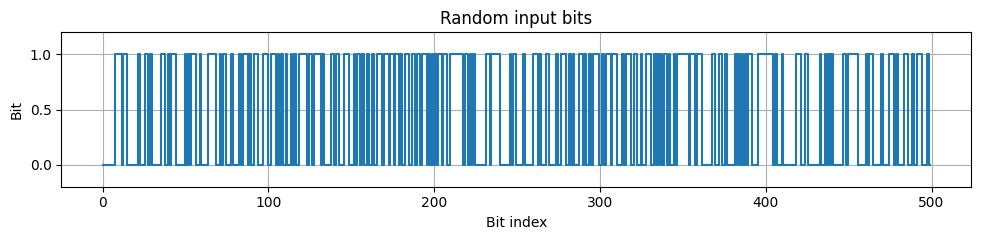

In [271]:
# --------------------------------------------------
# Parameters
# --------------------------------------------------
M = 64 #QAM modulation
bits_per_symbol = int(np.log2(M)) # 6 Bits for 64-QAM

fs_hz = 20e6 # Channel Bandwidth
n_fft = 64   # FFT Size
cp_len = 16  # Cyclic Prefix Length
n_data_subcarriers = 52 # Number of true data subcarriers
num_ofdm_symbols = 64   # Number of Symbols

n_qam_symbols_transmitted = num_ofdm_symbols * n_data_subcarriers # Actual Transmitted QAM Symbols

# --------------------------------------------------
# Generate bits (Pseudo Random)
# --------------------------------------------------
dummy_sig = Signal(x=np.array([], dtype=np.uint8), fs_hz=fs_hz, meta={"name": "PRBS15 Input Bits"})

prbs_gen = PRBSBitSource(
    name="tx_bits",
    params=PRBSParams(
        order=15,
        n_bits=n_qam_symbols_transmitted * bits_per_symbol,
        seed=123,
    ),
)

sig_bits = prbs_gen.process(dummy_sig)
bits = sig_bits.x

print("Number of bits:", len(bits))
print("Expected QAM symbols:", n_qam_symbols_transmitted)
print("Bits per symbol:", bits_per_symbol)
print(sig_bits.meta)
plot_bits(bits, n_bits=500, title="Random input bits")


# Allocate symbols to QAM and OFDM

In [272]:
# --------------------------------------------------
# QAM modulation
# --------------------------------------------------
qam = QAMModulator(
    "qam1",
    QAMParams(
        M=M,
        gray_map=True,
        unit_average_power=True,
    )
)

sig_qam = qam.process(sig_bits)
qam_symbols = sig_qam.x

# --------------------------------------------------
# OFDM modulation
# --------------------------------------------------
ofdm = OFDMModulator(
    "ofdm1",
    OFDMParams(
        n_fft=n_fft,
        cp_len=cp_len,
        n_data_subcarriers=n_data_subcarriers,
        normalize_ifft=True,
        null_dc=True,
    )
)

sig_ofdm = ofdm.process(sig_qam)
tx_input = sig_ofdm.x

print("OFDM output samples:", len(tx_input))
print("Expected samples:", num_ofdm_symbols * (n_fft + cp_len))

OFDM output samples: 5120
Expected samples: 5120


Target Power: -30 dBm
Actual Scaled Power: -30.00 dBm


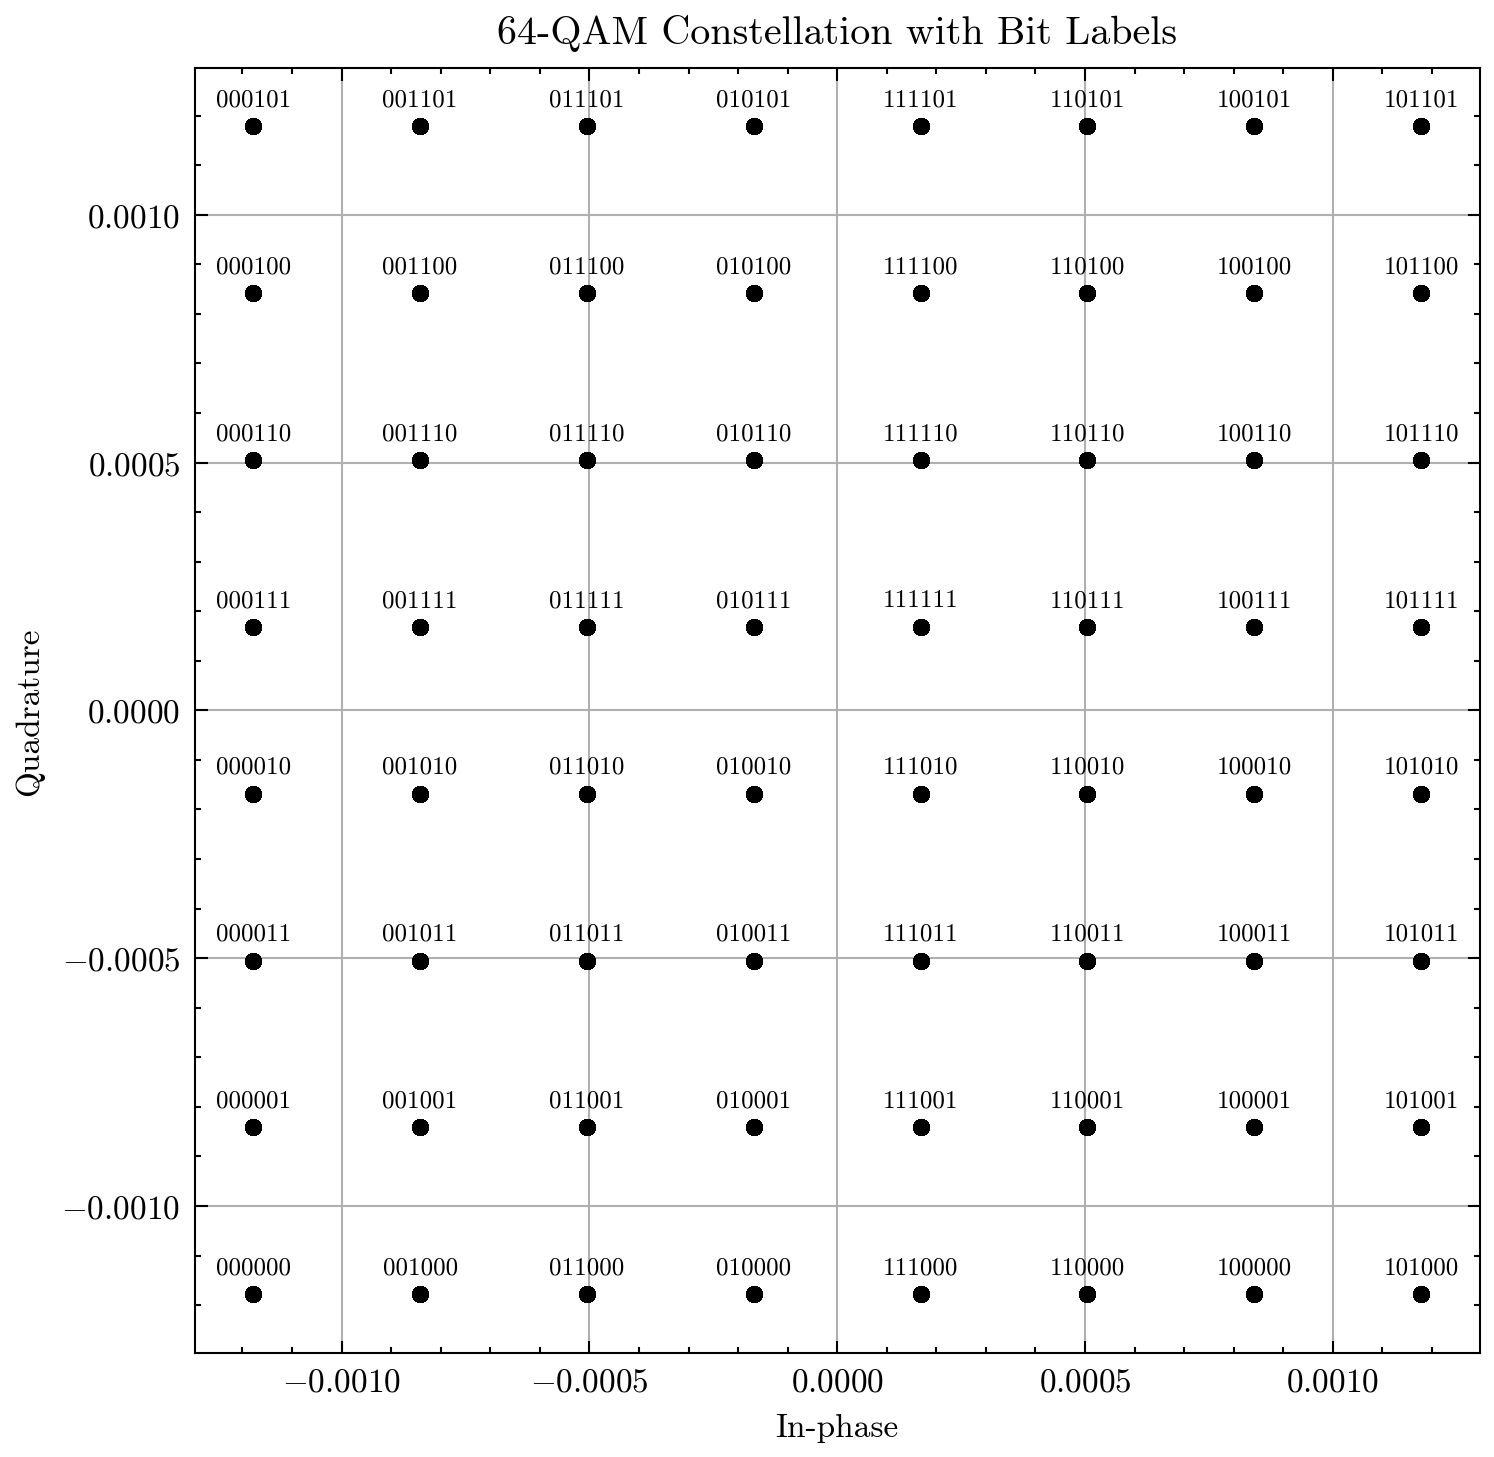

In [273]:
from rfmodel.core.units import dbm_to_w

# Define your target input power to the LNA/Pipeline
input_pwr_dbm = -30 

current_w      = np.mean(np.abs(sig_ofdm.x) ** 2)
target_w       = dbm_to_w(input_pwr_dbm)
scaling_factor = np.sqrt(target_w / current_w)

sig_ofdm_normalized = sig_ofdm.copy_with(x= sig_ofdm.x * scaling_factor)

actual_pwr_watts = np.mean(np.abs(sig_ofdm_normalized.x)**2)
actual_pwr_dbm = 10 * np.log10(actual_pwr_watts) + 30

print(f"Target Power: {input_pwr_dbm} dBm")
print(f"Actual Scaled Power: {actual_pwr_dbm:.2f} dBm")

plot_constellation_with_bits(                                                                                                                                                                                        
    symbols=ofdm.demodulate(sig_ofdm_normalized).x,
    bits=bits,                                                                                                                                                                                                       
    bits_per_symbol=bits_per_symbol,                      
    title="64-QAM Constellation with Bit Labels",
    science=True,
    fig_scale=2)


# PipeLine Initiation

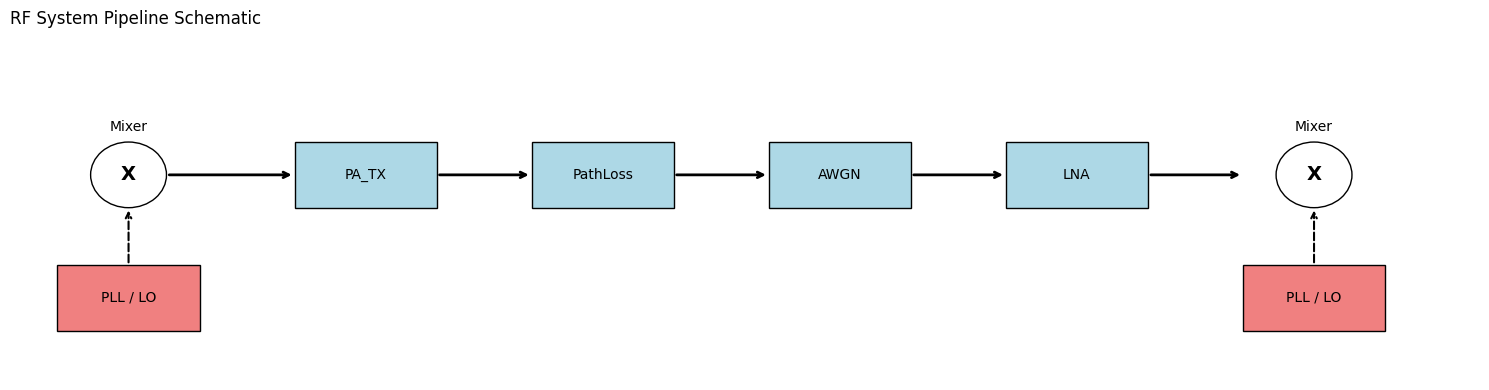

Input Peak:    0.003194
Peak after PA_TX   : 0.031747
Peak after PathLoss: 0.000124
Peak after AWGN    : 0.000125
Peak after LNA     : 0.001252


In [274]:
cfg = load_yaml(r".\Tx_channel_Rx.yaml")
pipe = pipeline_from_config(cfg)
mixer_tx = pipe.get("mixer_and_pll_TX")
mixer_tx.params.mixer_ideal = True
mixer_tx.params.pll.enable_ofdm_weighting = True

mixer_rx= pipe.get("mixer_and_pll_RX")
mixer_rx.params.mixer_ideal = True
mixer_rx.params.pll.enable_ofdm_weighting = True

plot_pipeline(pipe)

output_sig, taps = pipe.run(sig_ofdm_normalized, taps=["PA_TX", "PathLoss", "AWGN", "LNA"])

print(f"Input Peak:    {np.max(np.abs(sig_ofdm_normalized.x)):.6f}")

for block_name, signal in taps.items():
    peak = np.max(np.abs(signal.x))
    print(f"Peak after {block_name:8}: {peak:.6f}")

# Performance Evaluation 

## Link budget — simulated power per block


In [275]:
blocks   = {b["name"]: b["params"] for b in cfg["pipeline"]}                                                                                                                                                                     
c0       = 299792458.0                                                                                                                                                                                                           

# Gains/losses in dB
G_mix_tx = blocks["mixer_and_pll_TX"]["gain_db"]
G_pa     = blocks["PA_TX"]["gain_db"]
G_lna    = blocks["LNA"]["gain_db"]
G_mix_rx = blocks["mixer_and_pll_RX"]["gain_db"]

# Path loss (Friis) in dB
p        = blocks["PathLoss"]
lam      = c0 / float(p["freq_hz"])
L_path   = 10 * np.log10((lam / (4 * np.pi * p["distance_m"]))**2) + p["tx_ant_gain_db"] + p["rx_ant_gain_db"] 

# Stage-by-stage addition
P_in    = input_pwr_dbm
P_mix1  = P_in   + G_mix_tx
P_pa    = P_mix1 + G_pa
P_path  = P_pa   + L_path
P_awgn  = P_path + 0.0
P_end   = P_awgn

print("P_in      =", P_in,   "dBm")
print("Mixer TX  =", P_mix1, "dBm")
print("PA_TX     =", P_pa,   "dBm")
print("PathLoss  =", P_path, "dBm")
print("Prx  =", P_end,  "dBm")


P_in      = -30 dBm
Mixer TX  = -30 dBm
PA_TX     = -10.0 dBm
PathLoss  = -58.14778322188338 dBm
Prx  = -58.14778322188338 dBm


In [276]:
                                                                                                                                                        
def p_dbm(x):        
    return 10 * np.log10(np.mean(np.abs(x) ** 2)) + 30                                                                                                                                                                           
                                                                                                                                                                                                                                
tap_names = ["mixer_and_pll_TX", "PA_TX", "PathLoss", "AWGN", "LNA", "mixer_and_pll_RX"]      
print(p_dbm(sig_ofdm_normalized.x))                                                                                                                                   
_, taps   = pipe.run(sig_ofdm_normalized, taps=tap_names)                                                                                                                                                                        
                                                                                                                                                                                                                                
print("P_in      =", p_dbm(sig_ofdm_normalized.x),     "dBm")
print("Mixer TX  =", p_dbm(taps["mixer_and_pll_TX"].x), "dBm")
print("PA_TX     =", p_dbm(taps["PA_TX"].x),            "dBm")
print("PathLoss  =", p_dbm(taps["PathLoss"].x),         "dBm")
print("AWGN      =", p_dbm(taps["AWGN"].x),             "dBm")
print("P_rx      =", p_dbm(taps["AWGN"].x),             "dBm")


-30.0
P_in      = -30.0 dBm
Mixer TX  = -30.0 dBm
PA_TX     = -10.003443195913604 dBm
PathLoss  = -58.15122641779698 dBm
AWGN      = -58.14637459976878 dBm
P_rx      = -58.14637459976878 dBm


In [277]:
# --- Summary: analytical vs simulated link budget -----------------------                                                                                                                                                       
rows = [                               
    ("P_in",     P_in,   p_dbm(sig_ofdm_normalized.x)),                                                                                                                                                                          
    ("Mixer TX", P_mix1, p_dbm(taps["mixer_and_pll_TX"].x)),                                                                                                                                                                     
    ("PA_TX",    P_pa,   p_dbm(taps["PA_TX"].x)),                                                                                                                                                                                
    ("PathLoss", P_path, p_dbm(taps["PathLoss"].x)),                                                                                                                                                                             
    ("AWGN",     P_path, p_dbm(taps["AWGN"].x)),                                                                                                                                                                                 
    ("P_rx",     P_end,  p_dbm(taps["AWGN"].x)),                                                                                                                                                                                 
]     

print("Stage      P_an [dBm]   P_sim [dBm]   Δ [dB]")
for name, an, sim in rows:
    print(f"{name:<10} {an:>10.2f}   {sim:>10.2f}   {sim - an:>+7.2f}")

Stage      P_an [dBm]   P_sim [dBm]   Δ [dB]
P_in           -30.00       -30.00     +0.00
Mixer TX       -30.00       -30.00     +0.00
PA_TX          -10.00       -10.00     -0.00
PathLoss       -58.15       -58.15     -0.00
AWGN           -58.15       -58.15     +0.00
P_rx           -58.15       -58.15     +0.00


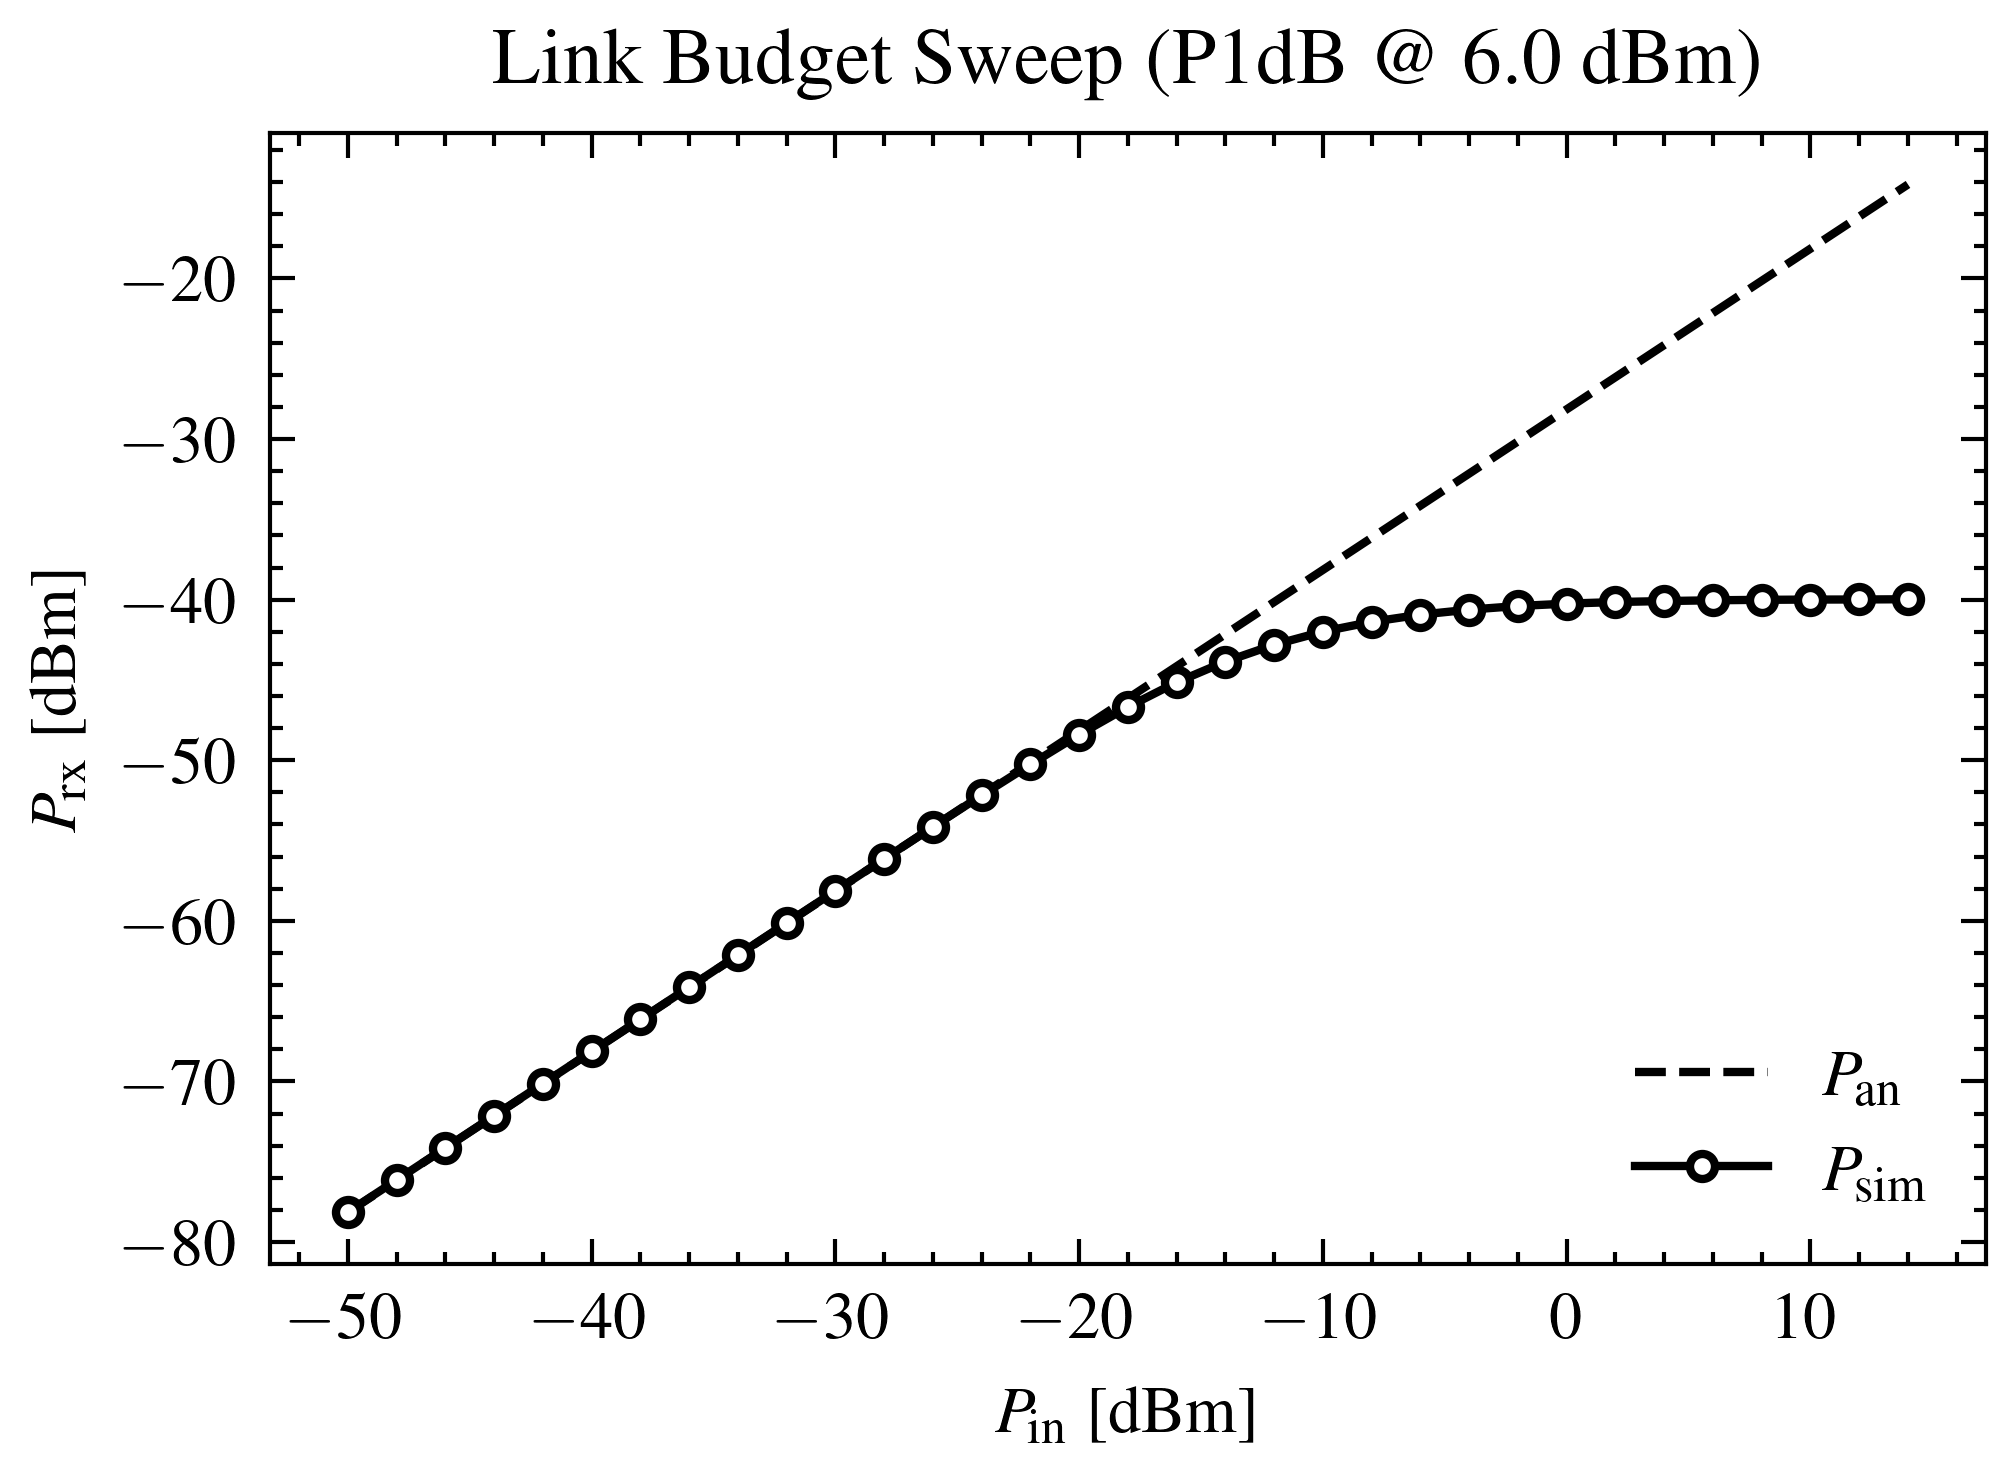

In [278]:
import scienceplots  # noqa: F401                                                                                                                                                                                                
                                                                                                                                                                                                                                
p_in_sweep_dbm = np.arange(-50.0, 15.0, 2.0)

G_tot_db  = P_end - P_in                           # analytical, up to P_rx (AWGN tap)
current_w = np.mean(np.abs(sig_ofdm.x) ** 2)

p_rx_sim = []
p_rx_an  = []

for pin in p_in_sweep_dbm:
    scale = np.sqrt(dbm_to_w(pin) / current_w)
    s_in  = sig_ofdm.copy_with(x=sig_ofdm.x * scale)
    _, taps_sw = pipe.run(s_in, taps=["AWGN"])     # stop at the receive antenna
    p_rx_sim.append(10 * np.log10(np.mean(np.abs(taps_sw["AWGN"].x) ** 2)) + 30)
    p_rx_an.append(pin + G_tot_db)

p_rx_sim = np.array(p_rx_sim)
p_rx_an  = np.array(p_rx_an)
delta    = p_rx_sim - p_rx_an

with plt.style.context(['science', 'ieee']):
    fig, ax1 = plt.subplots(figsize=(3.5, 2.6))

    l1, = ax1.plot(p_in_sweep_dbm, p_rx_an,  color='k', linestyle='--',
                    label=r'$P_\mathrm{an}$')
    l2, = ax1.plot(p_in_sweep_dbm, p_rx_sim, color='k', linestyle='-',
                    marker='o', markersize=3, markerfacecolor='white',
                    label=r'$P_\mathrm{sim}$')
    ax1.set_xlabel(r'$P_\mathrm{in}$ [dBm]')
    ax1.set_ylabel(r'$P_\mathrm{rx}$ [dBm]')

    ax1.legend(handles=[l1, l2], frameon=False, loc='lower right')
    plt.title(f"Link Budget Sweep (P1dB @ {blocks['PA_TX']['p1db_out_dbm']} dBm)")
    plt.tight_layout()
    plt.show()

# EVM

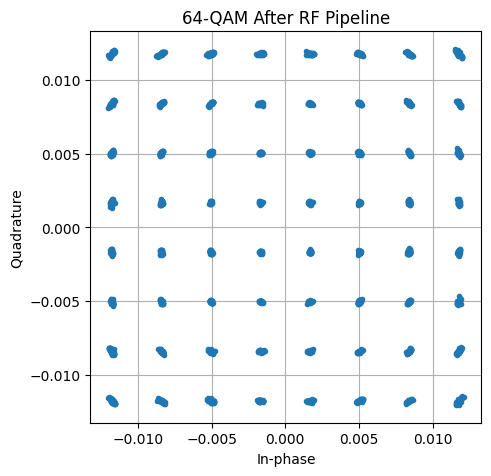

TX EVM (RMS): 1.09 %
TX EVM (RMS): -39.28 dB


In [279]:
output_sig, taps = pipe.run(sig_ofdm_normalized, taps=["PA_TX", "PathLoss", "AWGN", "LNA"])
_, taps = pipe.run(sig_ofdm_normalized, taps=["PA_TX"])
sig_demod = ofdm.demodulate(taps["PA_TX"])

plot_constellation(
    sig_demod.x,
    title="64-QAM After RF Pipeline",
    science=False,
    fig_scale=2
)

sig_pa = taps["PA_TX"]                                                                                                                                                                                                                                                                                                                                                                                                                      
sig_pa_demod = ofdm.demodulate(sig_pa)                                                                                                                                                                                                                                                                                                                                                                                                      
                                                                                                                                                                                                                                                                                                                                                                                                                                            
rx = sig_pa_demod.x                                                                                                                                                                                                                                                                                                                                                                                                                         
tx = qam_symbols                                                                                                                                                                                                                                                                                                                                                                                                                            
                                                                                                                                                                                                                                                                                                                                                                                                                                            
# Normalize rx to same power as ideal reference
rx_norm = rx * np.sqrt(np.mean(np.abs(tx)**2) / np.mean(np.abs(rx)**2))


error = rx_norm - tx
evm_rms = np.sqrt(np.mean(np.abs(error)**2) / np.mean(np.abs(tx)**2)) * 100

print(f"TX EVM (RMS): {evm_rms:.2f} %")
print(f"TX EVM (RMS): {20 * np.log10(evm_rms / 100):.2f} dB")


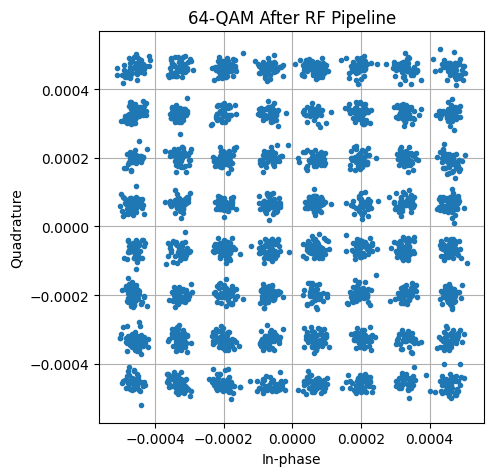

TX EVM (RMS): 5.69 %
TX EVM (RMS): -24.89 dB


In [280]:
sig_out, taps = pipe.run(sig_ofdm_normalized)
sig_demod = ofdm.demodulate(sig_out)

plot_constellation(
    sig_demod.x,
    title="64-QAM After RF Pipeline",
    science=False,
    fig_scale=2
)


rx = sig_demod.x                                                                                                                                                                                                                                                                                                                                                                                                                         
tx = qam_symbols                                                                                                                                                                                                                                                                                                                                                                                                                            

rx_norm = rx * np.sqrt(np.mean(np.abs(tx)**2) / np.mean(np.abs(rx)**2))

error = rx_norm - tx
evm_rms = np.sqrt(np.mean(np.abs(error)**2) / np.mean(np.abs(tx)**2)) * 100

print(f"TX EVM (RMS): {evm_rms:.2f} %")
print(f"TX EVM (RMS): {20 * np.log10(evm_rms / 100):.2f} dB")



# BER

In [281]:
from scipy.special import erfc

sig_ber_out, ber_taps = pipe.run(sig_ofdm_normalized, taps=["PathLoss", "AWGN"])

rx_syms = ofdm.demodulate(sig_ber_out).x

rx_syms_norm = rx_syms / np.sqrt(np.mean(np.abs(rx_syms) ** 2))

# --- Count bit errors ------------------------------------------------------
Bits_rx = qam.demap(rx_syms_norm)

if len(Bits_rx) != len(sig_bits.x):
    print("ERROR: length mismatch — cannot compute BER")
else:
    errors      = sig_bits.x ^ Bits_rx
    error_count = int(np.sum(errors))
    ber_sim     = error_count / len(sig_bits.x)

    # --- SNR at receiver (PathLoss tap = signal only, AWGN tap = signal+noise)
    noise   = ber_taps["AWGN"].x - ber_taps["PathLoss"].x
    sig_pwr = np.mean(np.abs(ber_taps["PathLoss"].x) ** 2)
    nse_pwr = np.mean(np.abs(noise) ** 2)
    snr_lin  = sig_pwr / nse_pwr
    snr_db   = 10 * np.log10(snr_lin)
    ebn0_lin = snr_lin / bits_per_symbol        # Eb/N0 = Es/N0 / log2(M)
    ebn0_db  = 10 * np.log10(ebn0_lin)

    # --- Analytical BER for Gray-coded 64-QAM AWGN -------------------------
    # BER ≈ (7/24) * erfc(sqrt(Eb/N0 / 7))
    ber_theory = (7 / 24) * erfc(np.sqrt(ebn0_lin / 7))

    print(f"Errors:       {error_count} / {len(sig_bits.x)} bits")
    print(f"BER (sim):    {ber_sim:.4e}  ({ber_sim*100:.3f} %)")
    print(f"BER (theory): {ber_theory:.4e}  ({ber_theory*100:.3f} %)")
    print(f"SNR (rx):     {snr_db:.2f} dB")
    print(f"Eb/N0:        {ebn0_db:.2f} dB")


Errors:       7 / 19968 bits
BER (sim):    3.5056e-04  (0.035 %)
BER (theory): 3.6745e-05  (0.004 %)
SNR (rx):     24.90 dB
Eb/N0:        17.11 dB


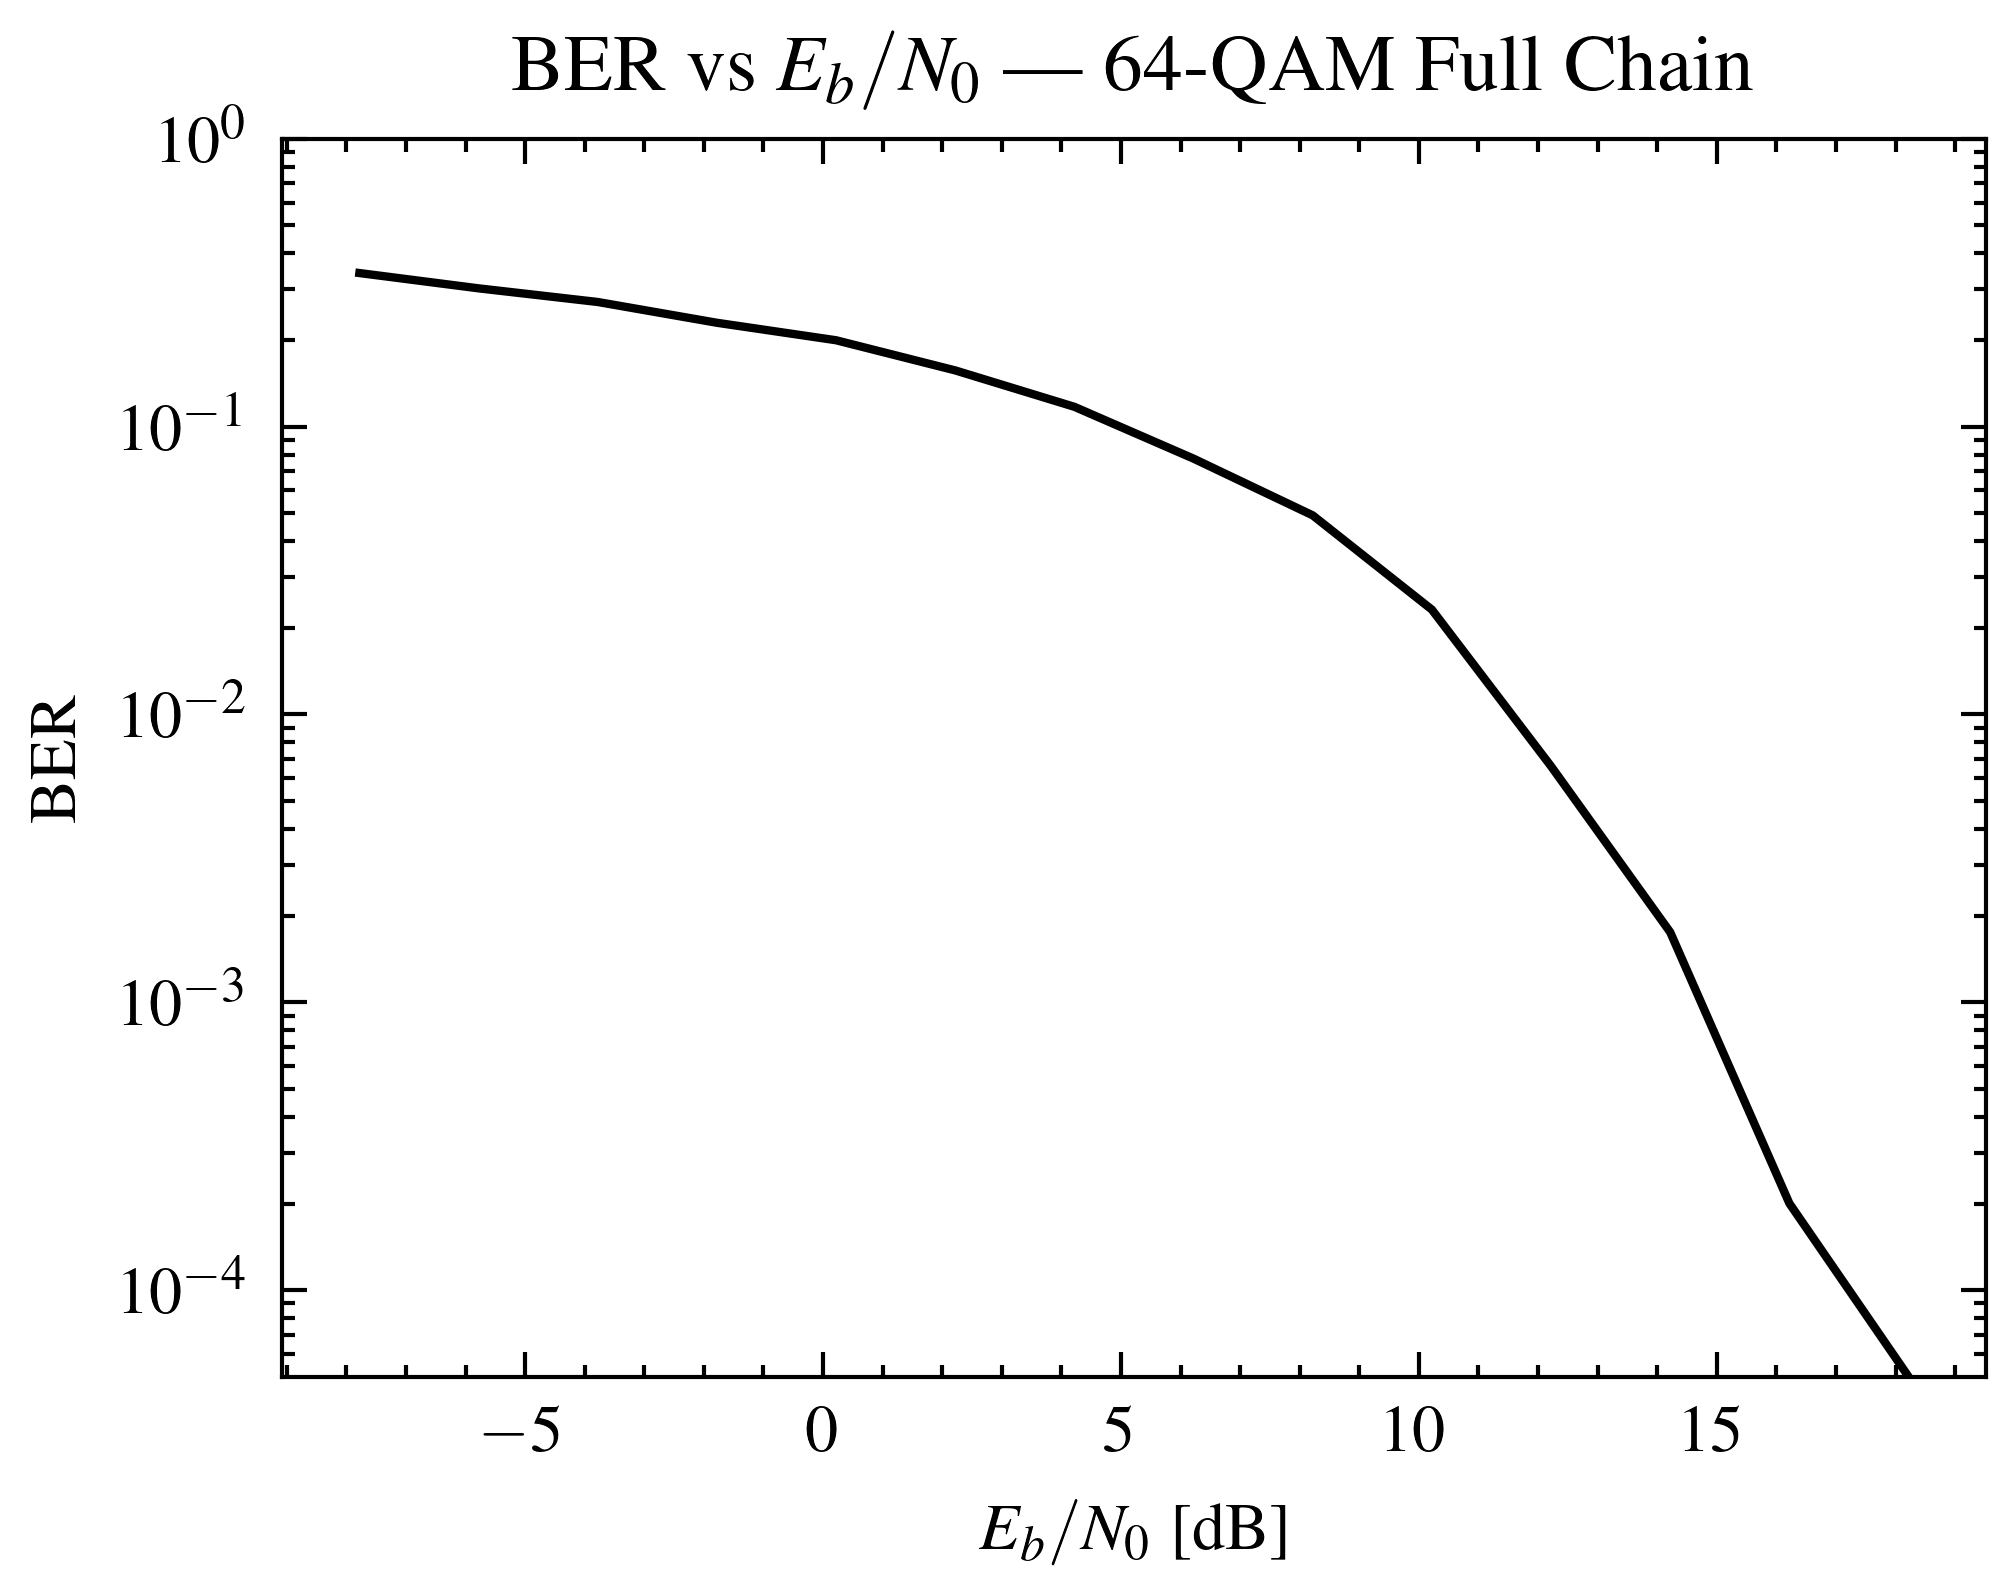

In [282]:
import scienceplots  # noqa: F401

awgn_block = pipe.get("AWGN")
snr_saved  = awgn_block.params.snr_db

snr_sweep_db  = np.arange(0, 30, 2)
ebn0_sweep_db = snr_sweep_db - 10 * np.log10(bits_per_symbol)

ebn0_list = []
ber_list  = []

for snr_db, ebn0_db in zip(snr_sweep_db, ebn0_sweep_db):
    awgn_block.params.snr_db = snr_db
    sig_out, _ = pipe.run(sig_ofdm_normalized)

    rx_norm = ofdm.demodulate(sig_out).x
    rx_norm = rx_norm / np.sqrt(np.mean(np.abs(rx_norm) ** 2))
    n_err   = int(np.sum(sig_bits.x ^ qam.demap(rx_norm)))

    if n_err > 0:
        ebn0_list.append(ebn0_db)
        ber_list.append(n_err / len(sig_bits.x))

awgn_block.params.snr_db = snr_saved

with plt.style.context(['science', 'ieee']):
    fig, ax = plt.subplots(figsize=(3.5, 2.8))
    ax.semilogy(ebn0_list, ber_list, color='k', linestyle='-')
    ax.set_xlabel(r'$E_b/N_0$ [dB]')
    ax.set_ylabel('BER')
    ax.set_ylim([ber_list[-1], 1])
    plt.title('BER vs $E_b/N_0$ — 64-QAM Full Chain')
    plt.tight_layout()
    plt.show()

